## Regression in Business
By the end of this module, you will be able to:
1. Build regression models using Statsmodels for business insights
2. Forecast key business KPIs with confidence intervals
3. Interpret diagnostic plots to validate model assumptions
4. Communicate findings to stakeholders effectively

In [1]:
# Install required packages (if needed)
!pip install statsmodels -q

# Core libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statsmodels for regression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, normal_ad
from statsmodels.graphics.gofplots import qqplot

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [6]:
# Upload the CSV file to Colab

# from google.colab import files
# uploaded = files.upload()

# Load data
df = pd.read_csv('business_sales_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f"📊 Dataset Shape: {df.shape}")
print(f"📅 Date Range: {df['Date'].min()} to {df['Date'].max()}")
(df.head())

📊 Dataset Shape: (48, 7)
📅 Date Range: 2020-01-01 00:00:00 to 2023-12-01 00:00:00


,Date,Marketing_Spend,Sales_Team_Size,Website_Traffic,Season,Previous_Quarter_Sales,Revenue
0,2020-01-01,15000,12,45000,Winter,280000,295000
1,2020-02-01,16500,12,48000,Winter,295000,310000
2,2020-03-01,18000,13,52000,Spring,310000,335000
3,2020-04-01,20000,13,58000,Spring,335000,365000
4,2020-05-01,22000,14,62000,Spring,365000,390000


In [7]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50 + "\n")

# Basic statistics
print("Descriptive Statistics:")
df.describe()

Missing Values:
Date                      0
Marketing_Spend           0
Sales_Team_Size           0
Website_Traffic           0
Season                    0
Previous_Quarter_Sales    0
Revenue                   0
dtype: int64


Descriptive Statistics:


,Date,Marketing_Spend,Sales_Team_Size,Website_Traffic,Previous_Quarter_Sales,Revenue
count,48,48.000000,48.000000,48.000000,48.000000,48.000000
mean,2021-12-15 23:00:00,26833.333333,19.916667,72833.333333,443500.000000,450583.333333
min,2020-01-01 00:00:00,15000.000000,12.000000,45000.000000,280000.000000,295000.000000
25%,2020-12-24 06:00:00,22750.000000,16.000000,62750.000000,388750.000000,397500.000000
50%,2021-12-16 12:00:00,26500.000000,20.000000,72000.000000,447500.000000,452500.000000
75%,2022-12-08 18:00:00,31000.000000,24.000000,82500.000000,501250.000000,506250.000000
max,2023-12-01 00:00:00,41000.000000,28.000000,105000.000000,580000.000000,620000.000000
std,NaN,5916.379476,4.676029,14144.141458,77083.265287,77360.398174


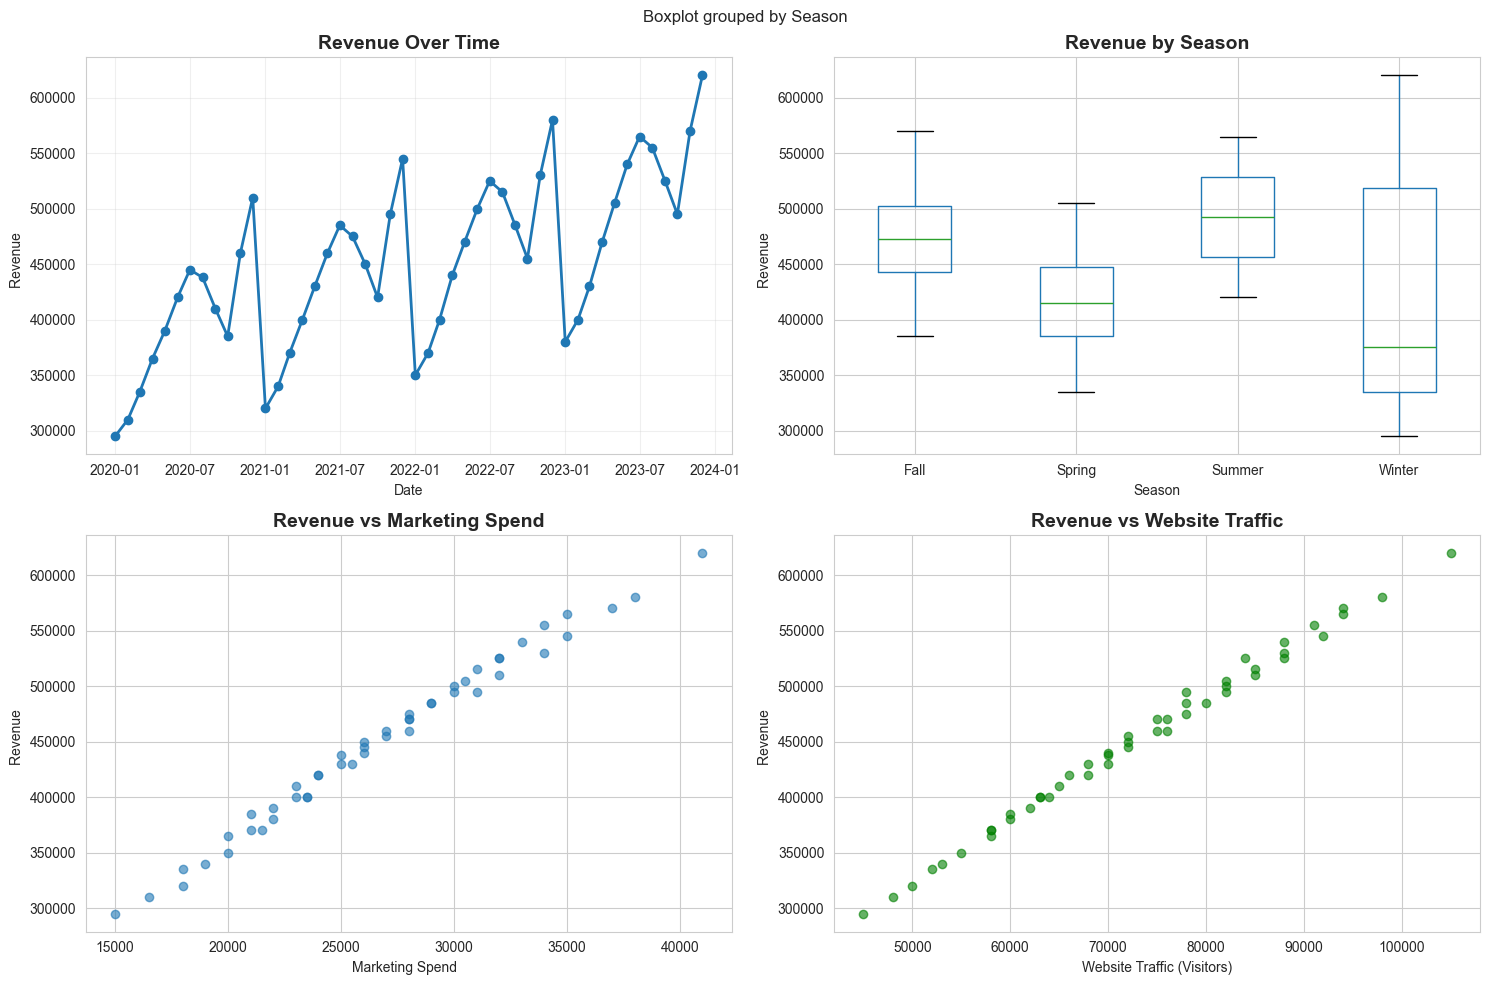


📈 Key Observation: Revenue differs by season, with higher median values in Summer and lower in Winter


In [8]:
# Visualize revenue trends
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Time series of revenue
axes[0, 0].plot(df['Date'], df['Revenue'], marker='o', linewidth=2)
axes[0, 0].set_title('Revenue Over Time', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Revenue  ')
axes[0, 0].grid(True, alpha=0.3)

# Revenue by season
df.boxplot(column='Revenue', by='Season', ax=axes[0, 1])
axes[0, 1].set_title('Revenue by Season', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Season')
axes[0, 1].set_ylabel('Revenue  ')

# Correlation with marketing spend
axes[1, 0].scatter(df['Marketing_Spend'], df['Revenue'], alpha=0.6)
axes[1, 0].set_title('Revenue vs Marketing Spend', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Marketing Spend  ')
axes[1, 0].set_ylabel('Revenue  ')

# Correlation with website traffic
axes[1, 1].scatter(df['Website_Traffic'], df['Revenue'], alpha=0.6, color='green')
axes[1, 1].set_title('Revenue vs Website Traffic', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Website Traffic (Visitors)')
axes[1, 1].set_ylabel('Revenue  ')

plt.tight_layout()
plt.show()

print("\n📈 Key Observation: Revenue differs by season, with higher median values in Summer and lower in Winter")

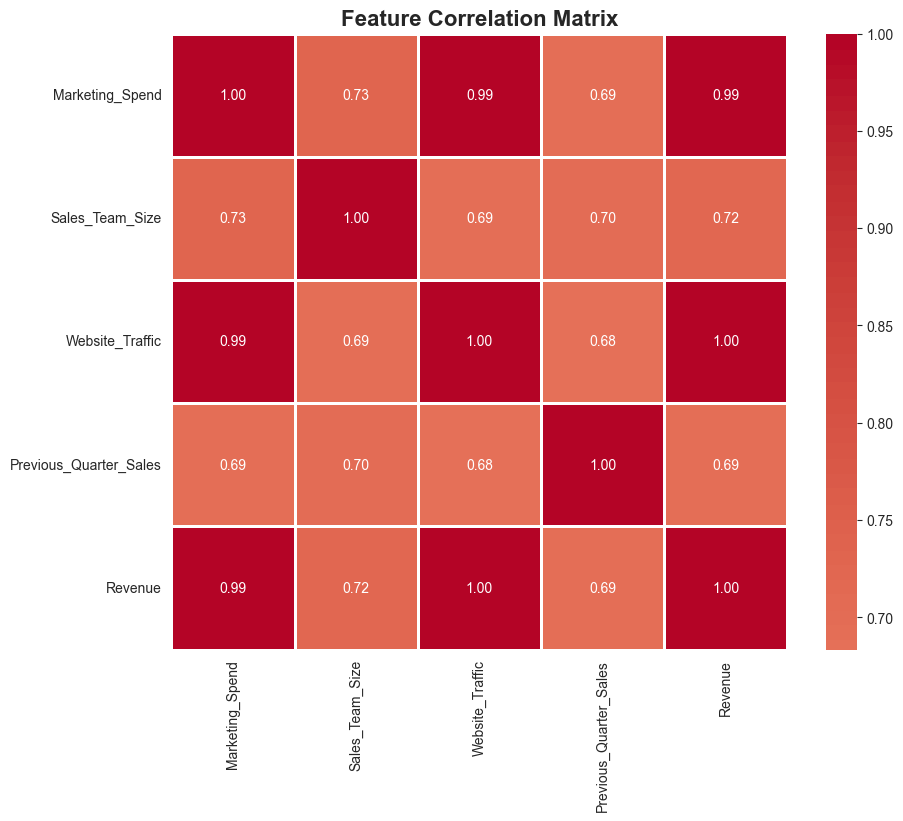


🔍 Insight: Website Traffic and Marketing Spend show high correlation with Revenue


In [9]:
# Correlation matrix
numeric_cols = ['Marketing_Spend', 'Sales_Team_Size', 'Website_Traffic', 'Previous_Quarter_Sales', 'Revenue']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.show()

print("\n🔍 Insight: Website Traffic and Marketing Spend show high correlation with Revenue")

In [10]:
# Create dummy variables for Season and convert boolean columns to int
df_model = pd.get_dummies(df, columns=['Season'], drop_first=True)
for col in ['Season_Spring', 'Season_Summer', 'Season_Winter']:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(int)

# Select features for modeling
feature_cols = ['Marketing_Spend', 'Sales_Team_Size', 'Website_Traffic',
                'Previous_Quarter_Sales', 'Season_Spring', 'Season_Summer', 'Season_Winter']

X = df_model[feature_cols]
y = df_model['Revenue']

print("Features selected:")
print(X.columns.tolist())
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Features selected:
['Marketing_Spend', 'Sales_Team_Size', 'Website_Traffic', 'Previous_Quarter_Sales', 'Season_Spring', 'Season_Summer', 'Season_Winter']

X shape: (48, 7)
y shape: (48,)


In [11]:
print("X dtypes:")
print(X.dtypes)
print("\ny dtypes:")
print(y.dtypes)

# Add constant term for intercept
X_with_const = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X_with_const)
results = model.fit()

# Display comprehensive summary
print(results.summary())

X dtypes:
Marketing_Spend           int64
Sales_Team_Size           int64
Website_Traffic           int64
Previous_Quarter_Sales    int64
Season_Spring             int64
Season_Summer             int64
Season_Winter             int64
dtype: object

y dtypes:
int64
                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     3283.
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           4.17e-53
Time:                        17:25:52   Log-Likelihood:                -455.38
No. Observations:                  48   AIC:                             926.8
Df Residuals:                      40   BIC:                             941.7
Df Model:                           7                                         
Covariance Type:        

In [16]:
# Extract key metrics programmatically
print("="*60)
print("KEY MODEL METRICS")
print("="*60)
print(f"R-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print(f"F-statistic: {results.fvalue:.2f}")
print(f"F-statistic p-value: {results.f_pvalue:.6f}")
print(f"AIC: {results.aic:.2f}")
print(f"BIC: {results.bic:.2f}")
print("="*60)

KEY MODEL METRICS
R-squared: 0.9983
Adjusted R-squared: 0.9980
F-statistic: 3282.50
F-statistic p-value: 0.000000
AIC: 926.76
BIC: 941.73



95% Confidence Intervals for Coefficients:
                         Coefficient      Lower_CI      Upper_CI       P-value
const                   64018.050892  49651.287720  78384.814064  3.615651e-11
Marketing_Spend             1.258440     -1.985446      4.502327  4.376233e-01
Sales_Team_Size           942.600174    462.264126   1422.936223  2.944465e-04
Website_Traffic             4.639605      3.302683      5.976528  1.793954e-08
Previous_Quarter_Sales      0.001926     -0.022299      0.026151  8.731258e-01
Season_Spring           -4900.076153  -8486.826417  -1313.325889  8.654967e-03
Season_Summer           -3767.786965  -8119.001146    583.427217  8.777244e-02
Season_Winter          -10326.482776 -13360.672416  -7292.293135  2.769898e-08


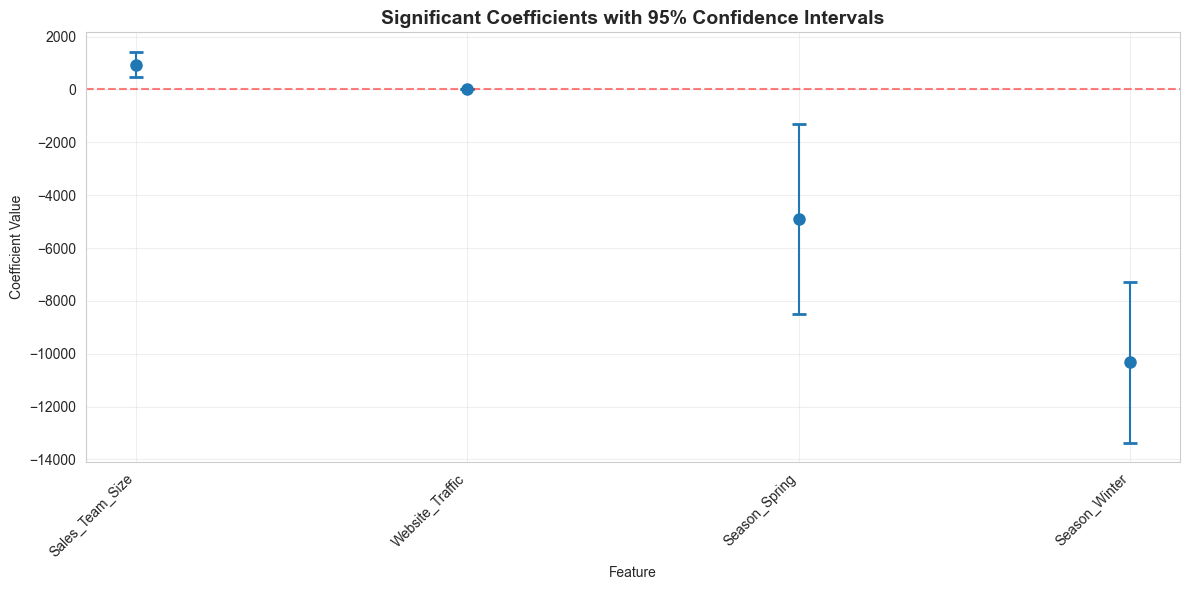

In [14]:
# Get 95% confidence intervals
conf_intervals = results.conf_int(alpha=0.05)
conf_intervals.columns = ['Lower_CI', 'Upper_CI']

# Combine with coefficients
coef_summary = pd.DataFrame({
    'Coefficient': results.params,
    'Lower_CI': conf_intervals['Lower_CI'],
    'Upper_CI': conf_intervals['Upper_CI'],
    'P-value': results.pvalues
})

print("\n95% Confidence Intervals for Coefficients:")
print(coef_summary)

# Visualize significant coefficients
sig_coef = coef_summary[coef_summary['P-value'] < 0.05].drop('const', errors='ignore')

plt.figure(figsize=(12, 6))
plt.errorbar(range(len(sig_coef)), sig_coef['Coefficient'],
             yerr=[sig_coef['Coefficient'] - sig_coef['Lower_CI'],
                   sig_coef['Upper_CI'] - sig_coef['Coefficient']],
             fmt='o', capsize=5, capthick=2, markersize=8)
plt.xticks(range(len(sig_coef)), sig_coef.index, rotation=45, ha='right')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('Feature')
plt.ylabel('Coefficient Value')
plt.title('Significant Coefficients with 95% Confidence Intervals', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()